In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os

print("=== Dataset Structure Summary ===")

# Enhanced: Loops through directories but only prints the folder names and file counts
# instead of flooding your screen with tens of thousands of individual image lines.
for dirname, dirnames, filenames in os.walk('/kaggle/input'):
    # Filter out hidden system files if any exist
    visible_files = [f for f in filenames if not f.startswith('.')]
    
    if visible_files:
        print(f"📁 {dirname}")
        print(f"   └── Contains {len(visible_files)} files\n")

=== Dataset Structure Summary ===
📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset
   └── Contains 1 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distorted images/368x368
   └── Contains 9500 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distorted images/92x92
   └── Contains 9500 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distortion-free images/368x368
   └── Contains 9500 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distortion-free images/92x92
   └── Contains 9500 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distortion-free images/720x480
   └── Contains 9500 files



**CELL:2**(Dataset structure)

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import gc

In [12]:
gc.collect()
torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", device)

Running on: cuda


In [13]:
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import torchvision.transforms as transforms

class LunarDataset(Dataset):
    def __init__(self, distorted_dir, clean_dir):
        self.distorted_dir = Path(distorted_dir)
        self.clean_dir = Path(clean_dir)

        self.image_names = sorted([
            img.name
            for img in self.distorted_dir.glob("*")
            if img.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ])

        self.transform = transforms.Compose([
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        image_name = self.image_names[idx]

        distorted = Image.open(
            self.distorted_dir / image_name
        ).convert("RGB")

        clean = Image.open(
            self.clean_dir / image_name
        ).convert("RGB")

        distorted = self.transform(distorted)
        clean = self.transform(clean)

        return distorted, clean

In [14]:
distorted_path = "/kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distorted images/368x368"
clean_path = "/kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distortion-free images/368x368"

train_dataset = LunarDataset(
    distorted_dir=distorted_path,
    clean_dir=clean_path
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

print("Training Images:", len(train_dataset))

Training Images: 9500


In [15]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [16]:
class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.down1 = DoubleConv(3,64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64,128)
        self.pool2 = nn.MaxPool2d(2)

        # Bottleneck
        self.middle = DoubleConv(128,256)

        # Decoder
        self.up1 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.conv1 = DoubleConv(256,128)

        self.up2 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.conv2 = DoubleConv(128,64)

        self.final = nn.Conv2d(64,3,1)

    def forward(self,x):

        x1 = self.down1(x)
        x2 = self.down2(self.pool1(x1))

        x3 = self.middle(self.pool2(x2))

        x = self.up1(x3)
        x = torch.cat([x,x2],dim=1)
        x = self.conv1(x)

        x = self.up2(x)
        x = torch.cat([x,x1],dim=1)
        x = self.conv2(x)

        return torch.sigmoid(self.final(x))

In [17]:
model = UNet().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0005
)

print(model)

UNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (middle): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  

In [18]:
from tqdm import tqdm

epochs = 10

for epoch in range(epochs):

    running_loss = 0

    progress = tqdm(train_loader)

    for distorted, clean in progress:

        distorted = distorted.to(device)
        clean = clean.to(device)

        prediction = model(distorted)

        loss = criterion(prediction, clean)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        progress.set_description(
            f"Epoch {epoch+1}/{epochs}"
        )

        progress.set_postfix(
            loss=loss.item()
        )

    print(
        f"Epoch {epoch+1} Average Loss = {running_loss/len(train_loader):.5f}"
    )

Epoch 1/10: 100%|██████████| 1188/1188 [11:12<00:00,  1.77it/s, loss=0.00793]


Epoch 1 Average Loss = 0.00932


Epoch 2/10: 100%|██████████| 1188/1188 [11:11<00:00,  1.77it/s, loss=0.00786]


Epoch 2 Average Loss = 0.00761


Epoch 3/10: 100%|██████████| 1188/1188 [11:11<00:00,  1.77it/s, loss=0.00686]


...

Epoch 8 Average Loss = 0.00589


Epoch 9/10: 100%|██████████| 1188/1188 [11:09<00:00,  1.77it/s, loss=0.00586]


Epoch 9 Average Loss = 0.00575


Epoch 10/10: 100%|██████████| 1188/1188 [11:10<00:00,  1.77it/s, loss=0.00623]

Epoch 10 Average Loss = 0.00563


In [21]:
torch.save(model.state_dict(),"lunavision_unet.pth")

print("U-Net saved successfully.")

U-Net saved successfully.


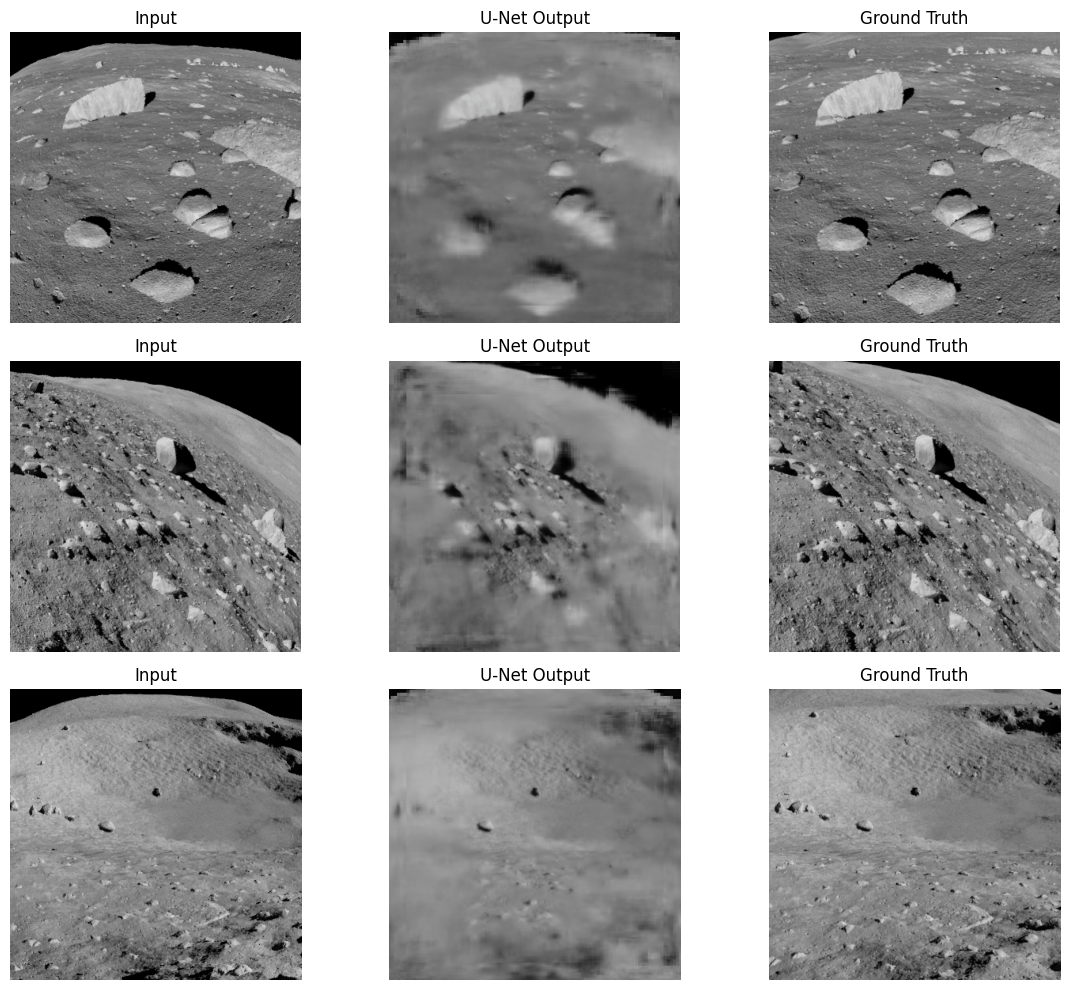

In [22]:
model.eval()

distorted_batch, clean_batch = next(iter(train_loader))

with torch.no_grad():

    prediction = model(distorted_batch.to(device)).cpu()

fig, axes = plt.subplots(3,3,figsize=(12,10))

for i in range(3):

    axes[i,0].imshow(distorted_batch[i].permute(1,2,0))
    axes[i,0].set_title("Input")
    axes[i,0].axis("off")

    axes[i,1].imshow(prediction[i].permute(1,2,0))
    axes[i,1].set_title("U-Net Output")
    axes[i,1].axis("off")

    axes[i,2].imshow(clean_batch[i].permute(1,2,0))
    axes[i,2].set_title("Ground Truth")
    axes[i,2].axis("off")

plt.tight_layout()
plt.show()